In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('data/placement.csv')
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


In [3]:
df.shape

(1000, 3)

C:\Users\narendra tekale\AppData\Local\Temp\ipykernel_3712\3792736820.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['cgpa'])
C:\Users\narendra tekale\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\narendra tekale\AppData\Local\Temp\ipykernel_3712\3792736820.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level functio

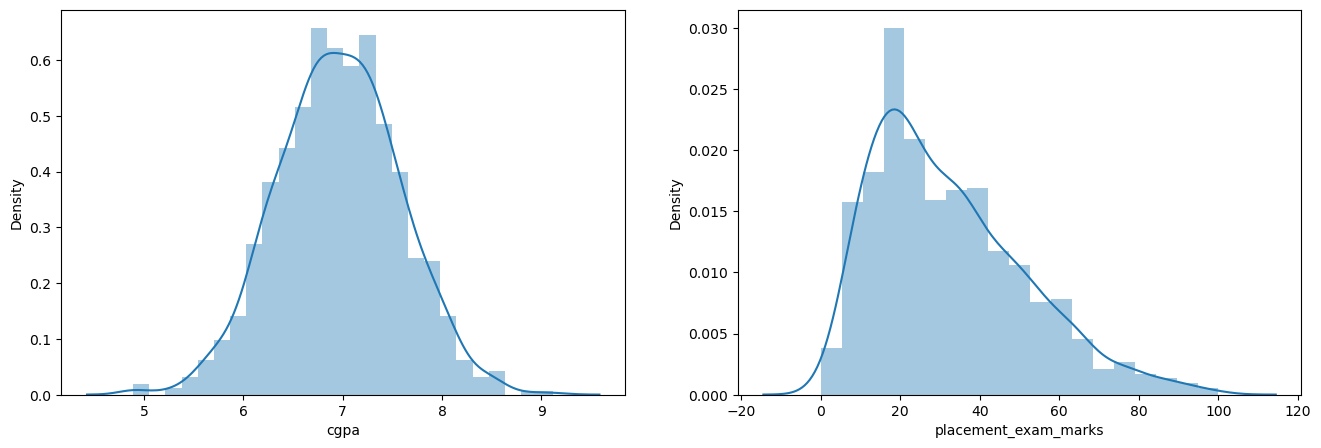

In [4]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.distplot(df['cgpa'])

plt.subplot(1,2,2)
sns.distplot(df['placement_exam_marks'])

plt.show()

In [5]:
print("Mean value of cgpa",df['cgpa'].mean())
print("std value of cgpa",df['cgpa'].std())
print("Maximum value of cgpa",df['cgpa'].max())
print("Minimum value of cgpa",df['cgpa'].min())

Mean value of cgpa 6.96124
std value of cgpa 0.6158978751323894
Maximum value of cgpa 9.12
Minimum value of cgpa 4.89


In [6]:
df['cgpa'].skew()

-0.014529938929314918

In [7]:
df['placement_exam_marks'].skew()

0.8356419499466834

In [11]:
df['placement_exam_marks'].describe()

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

<Axes: >

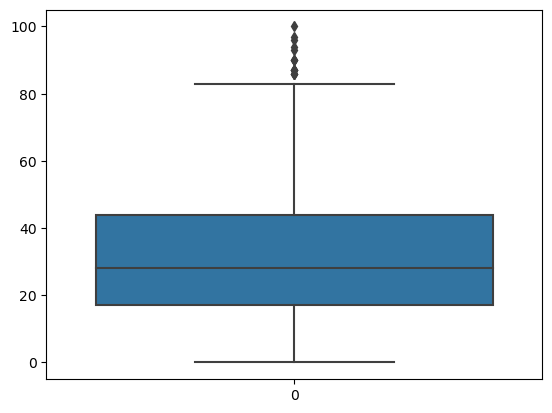

In [8]:
sns.boxplot(df['placement_exam_marks'])

In [12]:
iqr = 44-17

In [16]:
upper_limit = 44 + 1.5*iqr
lower_limit = 17 - 1.5*iqr

In [18]:
print("Upper Limit",upper_limit)
print("Lower Limit",lower_limit)

Upper Limit 84.5
Lower Limit -23.5


#### Finding Outlier

In [19]:
df[df['placement_exam_marks'] > upper_limit]

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


### Trimming

In [22]:
new_df = df[df['placement_exam_marks'] < upper_limit]

In [23]:
new_df.shape

(985, 3)

C:\Users\narendra tekale\AppData\Local\Temp\ipykernel_3712\1607610984.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['placement_exam_marks'])
C:\Users\narendra tekale\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\narendra tekale\AppData\Local\Temp\ipykernel_3712\1607610984.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figu

<Axes: >

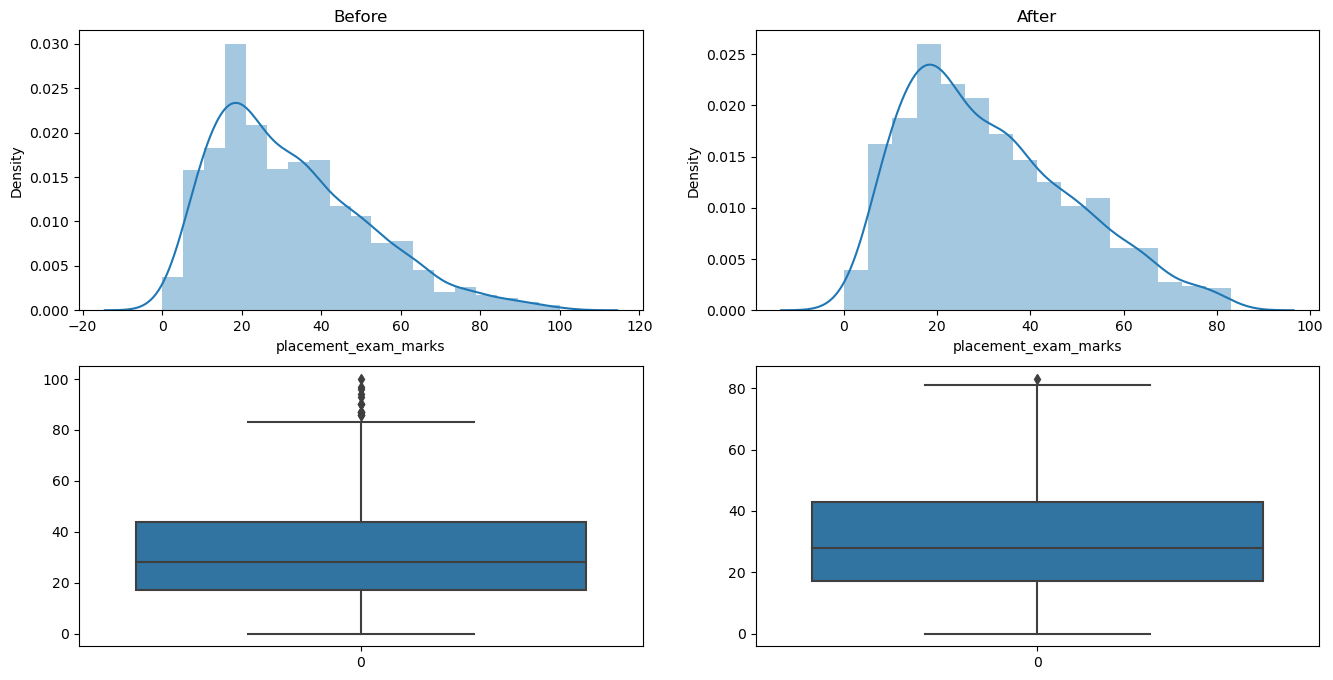

In [31]:
plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
plt.title("Before")
sns.distplot(df['placement_exam_marks'])

plt.subplot(2,2,2)
plt.title("After")
sns.distplot(new_df['placement_exam_marks'])

plt.subplot(2,2,3)
sns.boxplot(df['placement_exam_marks'])

plt.subplot(2,2,4)
sns.boxplot(new_df['placement_exam_marks'])

In [32]:
new_df_cap = df.copy()

In [33]:
new_df_cap['placement_exam_marks'] = np.where(
new_df_cap['placement_exam_marks'] > upper_limit ,
upper_limit,
np.where(
new_df_cap['placement_exam_marks'] < lower_limit,
lower_limit,
new_df_cap['placement_exam_marks']))

In [34]:
new_df_cap.shape

(1000, 3)

<Axes: >

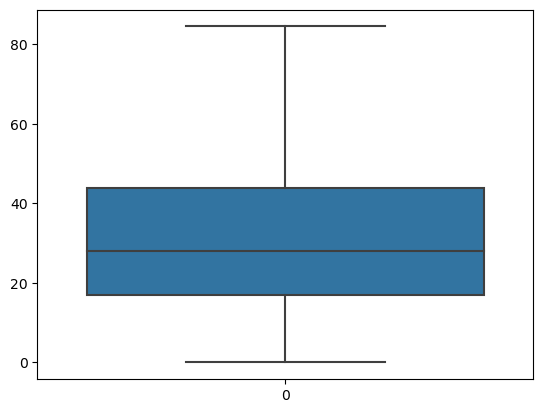

In [35]:
sns.boxplot(new_df_cap['placement_exam_marks'])

C:\Users\narendra tekale\AppData\Local\Temp\ipykernel_3712\3487199714.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df_cap['placement_exam_marks'])
C:\Users\narendra tekale\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='placement_exam_marks', ylabel='Density'>

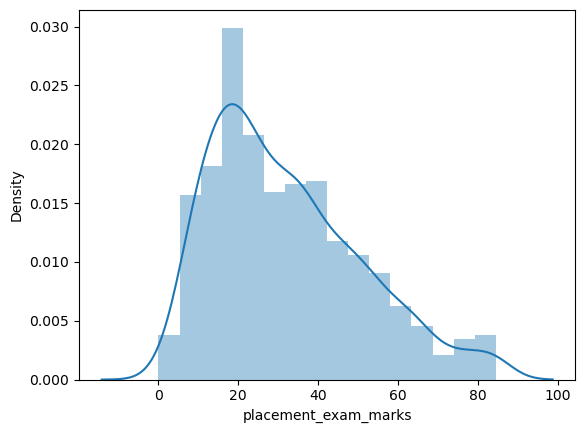

In [36]:
sns.distplot(new_df_cap['placement_exam_marks'])